### Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/processed/online_retail.csv")

In [3]:
X = df.drop(columns=['InvoiceDate', 'Invoice', 'StockCode', 'Customer ID'])

In [4]:
customer_features = df.copy()

In [5]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=78)
X_pca = pca.fit_transform(X_scaled)

Using PCA to reduce dimensionality so clusters can be visualized.

Also i chose it instead of UMAP or T-SNE, because there're 780k of rows and PCA is the fastest version of dimension reduction.

---

### K-Means analysis

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=78
)

In [7]:
labels = kmeans.fit_predict(X_scaled)

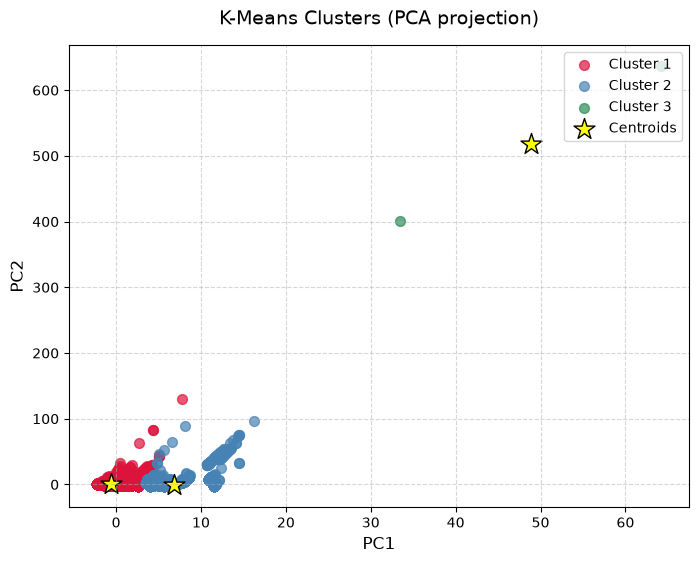

In [8]:
plt.figure(figsize=(8, 6))

colors = ["crimson", "steelblue", "seagreen"]

for cluster_id, color in enumerate(colors):
    mask = labels == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=50,
        c=color,
        alpha=0.7,
        label=f"Cluster {cluster_id + 1}",
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Centroids",
)

plt.title("K-Means Clusters (PCA projection)", fontsize=14, pad=15)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

---

### Inspecting clusters and outliers in it 

Before removing the "outlier" cluster, let's check how many rows/customers, and whether the extreme values are real.

In [9]:
cluster_summary = (
    df.assign(cluster=labels)
    .groupby("cluster")
    .agg(
        n_rows=("Invoice", "count"),
        n_customers=("Customer ID", "nunique"),
        avg_quantity=("Quantity", "mean"),
        avg_total_revenue=("total_revenue", "mean"),
        avg_num_orders=("num_orders", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_cancelled_orders=("sum_cancelled_orders", "mean"),
    )
    .round(2)
)

cluster_summary

,n_rows,n_customers,avg_quantity,avg_total_revenue,avg_num_orders,avg_recency_days,avg_cancelled_orders
cluster,,,,,,,
0,718699,5861,11.65,7909.17,16.73,88.27,3.93
1,60722,23,32.72,173242.36,230.70,2.83,58.75
2,2,2,77605.00,123014.48,7.00,162.50,3.50


In the second cluster i found out that there's only two customers which buying products pretty rarely but with high quantity and because of it revenue.

I'll drop them because they distort my plot so i can't analyze properly other type of clusters.

---

### Dropping the outlier cluster

PCA doesn't reorder rows — `X_pca[i]` still corresponds to `df.iloc[i]`

So I can drop the outlier customers by filtering on the cluster labels, not on the PCA coordinates

In [10]:
outlier_cluster = 2

keep_mask = labels != outlier_cluster

df_clean = df[keep_mask].reset_index(drop=True)
X_clean = X[keep_mask].reset_index(drop=True)

X_scaled_clean = X_scaled[keep_mask]
X_pca_clean = X_pca[keep_mask]

print(f"Rows before: {len(df)} -> after: {len(df_clean)}")

Rows before: 779423 -> after: 779421


In [11]:
kmeans_clean = KMeans(n_clusters=3, random_state=78)
labels_clean = kmeans_clean.fit_predict(X_scaled_clean)

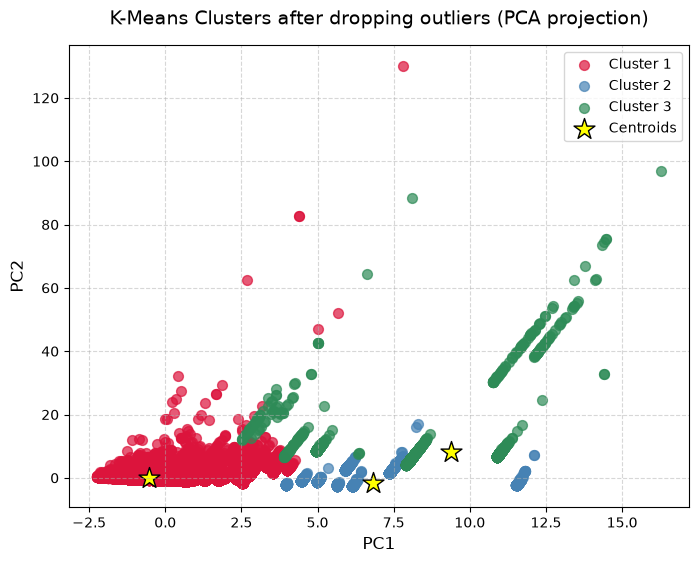

In [12]:
plt.figure(figsize=(8, 6))

colors = ["crimson", "steelblue", "seagreen"]

for cluster_id, color in enumerate(colors):
    mask = labels_clean == cluster_id
    plt.scatter(
        X_pca_clean[mask, 0],
        X_pca_clean[mask, 1],
        s=50,
        c=color,
        alpha=0.7,
        label=f"Cluster {cluster_id + 1}",
    )

centroids_pca = pca.transform(kmeans_clean.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Centroids",
)

plt.title("K-Means Clusters after dropping outliers (PCA projection)", fontsize=14, pad=15)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

---

### Clusters overlapping fix

In [13]:
customer_cols = [
    "avg_order_value",
    "avg_items_per_order",
    "num_orders",
    "num_products",
    "total_items",
    "avg_unit_price",
    "total_revenue",
    "sum_cancelled_orders",
    "customer_lifetime_days",
    "recency_days",
    "purchase_frequency",
]

cust = df.groupby("Customer ID")[customer_cols].first().reset_index()
print(f"Customers: {len(cust)}  (was {len(df)} rows)")

Customers: 5878  (was 779423 rows)


In [14]:
X_cust = cust.drop(columns=["Customer ID"])
X_cust_scaled = StandardScaler().fit_transform(X_cust)

pca_cust = PCA(n_components=2, random_state=78)
X_cust_pca = pca_cust.fit_transform(X_cust_scaled)

print("Explained variance (2 PCs):", pca_cust.explained_variance_ratio_.round(4).tolist())

Explained variance (2 PCs): [0.364, 0.1663]


- PCA with 2 components explains `only ~52% of variance` — the 2D view squashes real separation.

In [15]:
kmeans_cust = KMeans(n_clusters=3, random_state=78, n_init=10)
labels_cust = kmeans_cust.fit_predict(X_cust_scaled)

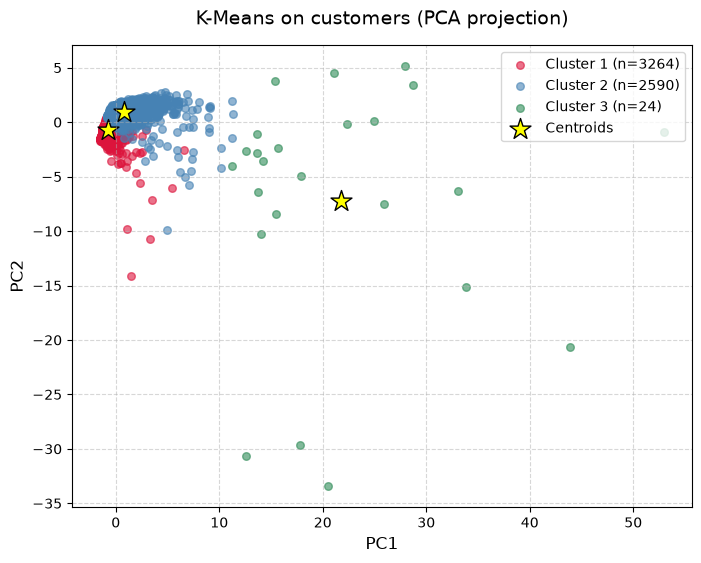

In [16]:
plt.figure(figsize=(8, 6))

colors = ["crimson", "steelblue", "seagreen"]

for cluster_id, color in enumerate(colors):
    mask = labels_cust == cluster_id
    plt.scatter(
        X_cust_pca[mask, 0],
        X_cust_pca[mask, 1],
        s=30,
        c=color,
        alpha=0.6,
        label=f"Cluster {cluster_id + 1} (n={mask.sum()})",
    )

centroids_pca = pca_cust.transform(kmeans_cust.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Centroids",
)

plt.title("K-Means on customers (PCA projection)", fontsize=14, pad=15)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)

plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The overlap is mostly a projection and duplication artifact, not bad clustering:

- `68% of rows are exact duplicate feature vectors` (same customer, repeated rows). The dense "one point" is ~944 identical rows.

UMAP / t-SNE would make a prettier picture but are stochastic, slow on 780k rows, and don't fix the row-level duplication, so i won't use it.

---